In [15]:
# # ============================================================
# # CELL 0: INSTALL ALL REQUIRED PACKAGES (run once, then restart kernel)
# # ============================================================
# import subprocess
# import sys

# # Uninstall any existing CPU-only torch build first
# subprocess.run([sys.executable, "-m", "pip", "uninstall", "torch", "torchvision", "torchaudio", "-y"])

# # Install CUDA-enabled PyTorch
# subprocess.run([
#     sys.executable, "-m", "pip", "install", "torch", "torchvision",
#     "--index-url", "https://download.pytorch.org/whl/cu121"
# ])

# # Install remaining packages used across the notebook
# subprocess.run([
#     sys.executable, "-m", "pip", "install",
#     "scikit-learn", "numpy", "matplotlib", "pillow", "jupyterlab", "tqdm"
# ])

# print("\nDone. RESTART THE KERNEL now (Kernel -> Restart) before running any other cells.")

In [16]:
# ============================================================
# CELL 1: CONFIG — change MODEL_NAME / TRAIN_MODE here per run
# ============================================================
import os, time, json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "Medicinal Plant Leaf Health Split Dataset"   # SAME for all models — do not change per model
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "shufflenet_v2"   # mobilenet_v3_small | shufflenet_v2 | efficientnet_b0
TRAIN_MODE = "full"                  # full | partial | classifier_only
PARTIAL_UNFREEZE_LAST_N = 2

# each model+mode combo writes to its OWN folder automatically -> safe to rerun for all combos
RUN_TAG = f"{MODEL_NAME}_{TRAIN_MODE}"
SAVE_DIR = os.path.join("checkpoints", RUN_TAG)
os.makedirs(SAVE_DIR, exist_ok=True)
CKPT_PATH = os.path.join(SAVE_DIR, "last_checkpoint.pth")
BEST_PATH = os.path.join(SAVE_DIR, "best_model.pth")
RESULTS_PATH = os.path.join(SAVE_DIR, "results.json")
CURVES_PATH = os.path.join(SAVE_DIR, "curves.png")
HISTORY_PATH = os.path.join(SAVE_DIR, "history.json")

print(f"Data source (shared across all runs): {DATA_DIR}")
print(f"This run's outputs will be saved to: {SAVE_DIR}")

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: No GPU detected — training will run on CPU and be very slow.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Data source (shared across all runs): Medicinal Plant Leaf Health Split Dataset
This run's outputs will be saved to: checkpoints/shufflenet_v2_full
CUDA available: True
GPU: NVIDIA GeForce RTX 3050
CUDA version: 12.1
Using device: cuda


In [17]:
# ============================================================
# CELL 2: TRANSFORMS — train gets augmentation, val/test don't
# ============================================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [18]:
# ============================================================
# CELL 3: LOAD DATA — reads from your existing train/val/test folders
# Verifies each split's 16 class subfolders and image counts
# ============================================================
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_ds.classes)
print(f"Classes ({NUM_CLASSES}): {train_ds.classes}")
print(f"Train images: {len(train_ds)} | Val images: {len(val_ds)} | Test images: {len(test_ds)}")

# sanity check: same 16 classes in every split, in the same order
assert train_ds.classes == val_ds.classes == test_ds.classes, "Class folder mismatch between splits!"
print("Class folders match across train/val/test ✓")

# ============================================================
# AUGMENTATION COUNT INFO
# ============================================================
print(f"\nOriginal training images (on disk): {len(train_ds)}")
print("Note: augmentation here is applied ON-THE-FLY (random transforms per epoch),")
print("so no new image files are created — each epoch sees the same 1,323-based split,")
print("but each training image gets a randomly different augmented version every epoch.")
print(f"Effective images seen per training epoch: {len(train_ds)} (same count, transformed each time)")
print(f"Effective images seen across all {EPOCHS} epochs: {len(train_ds) * EPOCHS}")

Classes (16): ['Aloe Vera Disease', 'Aloe Vera Dried', 'Aloe Vera Mature Healthy', 'Aloe Vera Young Healthy', 'Azadirachta Indica Chlorotic', 'Azadirachta Indica Disease', 'Azadirachta Indica Healthy', 'Hibiscus Rosa Sinensis Chlorotic', 'Hibiscus Rosa Sinensis Disease', 'Hibiscus Rosa Sinensis Healthy', 'Kalanchoe Pinnata Chlorotic', 'Kalanchoe Pinnata Disease', 'Kalanchoe Pinnata Healthy', 'Piper Betle Chlorotic', 'Piper Betle Disease', 'Piper Betle Healthy']
Train images: 924 | Val images: 199 | Test images: 200
Class folders match across train/val/test ✓

Original training images (on disk): 924
Note: augmentation here is applied ON-THE-FLY (random transforms per epoch),
so no new image files are created — each epoch sees the same 1,323-based split,
but each training image gets a randomly different augmented version every epoch.
Effective images seen per training epoch: 924 (same count, transformed each time)
Effective images seen across all 30 epochs: 27720


In [19]:
# ============================================================
# CELL 4: CLASS WEIGHTS — compensates for imbalance (52–153 per class)
# ============================================================
class_counts = np.bincount([label for _, label in train_ds.samples])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Per-class training image counts:", class_counts)
print("Computed class weights:", class_weights.cpu().numpy())

Per-class training image counts: [ 48  43  41  40  83  87 107  52  46  50  41  51  36  76  66  57]
Computed class weights: [1.0930157  1.2201105  1.279628   1.3116188  0.6321054  0.6030431
 0.49032477 1.0089375  1.1405381  1.0492951  1.279628   1.0287206
 1.4573542  0.6903257  0.79492044 0.92043424]


In [20]:
# ============================================================
# CELL 5: MODEL BUILDER — swaps in MobileNetV3 / ShuffleNetV2 / EfficientNet-B0
# ============================================================
def build_model(name, num_classes):
    if name == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
        feature_module = m.features
    elif name == "shufflenet_v2":
        m = models.shufflenet_v2_x1_0(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        feature_module = nn.Sequential(m.conv1, m.maxpool, m.stage2, m.stage3, m.stage4, m.conv5)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        feature_module = m.features
    else:
        raise ValueError(f"Unknown model: {name}")
    return m, feature_module

In [21]:
# ============================================================
# CELL 6: FREEZE/UNFREEZE LOGIC — controls full / partial / classifier_only
# ============================================================
def apply_train_mode(model, feature_module, mode, unfreeze_last_n=2):
    for p in model.parameters():
        p.requires_grad = False

    if mode == "full":
        for p in model.parameters():
            p.requires_grad = True
    elif mode == "classifier_only":
        for name, p in model.named_parameters():
            if "classifier" in name or name.startswith("fc."):
                p.requires_grad = True
    elif mode == "partial":
        children = list(feature_module.children())
        unfreeze_blocks = children[-unfreeze_last_n:] if unfreeze_last_n > 0 else []
        for block in unfreeze_blocks:
            for p in block.parameters():
                p.requires_grad = True
        for name, p in model.named_parameters():
            if "classifier" in name or name.startswith("fc."):
                p.requires_grad = True
    else:
        raise ValueError(f"Unknown TRAIN_MODE: {mode}")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"[{mode}] Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    return model

model, feature_module = build_model(MODEL_NAME, NUM_CLASSES)
model = apply_train_mode(model, feature_module, TRAIN_MODE, PARTIAL_UNFREEZE_LAST_N)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /home/nafim/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 13.3MB/s]

[full] Trainable params: 1,270,004 / 1,270,004 (100.00%)


In [22]:
# ============================================================
# CELL 7: LOSS / OPTIMIZER — only trainable params passed to optimizer
# ============================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(trainable_params, lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)

In [23]:
# ============================================================
# CELL 8: EPOCH RUNNER FUNCTION — one pass over a loader (train or eval)
# ============================================================
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1, precision, recall

In [24]:
# ============================================================
# CELL 9: CHECKPOINT RESUME — auto-continues if this cell reruns after interruption
# ============================================================
start_epoch = 1
best_val_f1 = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

if os.path.exists(CKPT_PATH):
    print(f"Resuming from checkpoint: {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_f1 = ckpt["best_val_f1"]
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    print(f"Resumed at epoch {start_epoch}, best_val_f1={best_val_f1:.4f}")

In [25]:
# ============================================================
# CELL 10: TRAINING LOOP — trains, saves checkpoint + best model every epoch
# ============================================================
from tqdm.notebook import tqdm

def run_epoch(loader, train=True, desc="Epoch"):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    pbar = tqdm(loader, desc=desc, leave=False)
    with context:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1, precision, recall


for epoch in range(start_epoch, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=True, desc=f"Epoch {epoch}/{EPOCHS} [train]")
    val_loss, val_acc, val_f1, val_prec, val_rec = run_epoch(val_loader, train=False, desc=f"Epoch {epoch}/{EPOCHS} [val]")
    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"[{RUN_TAG}] Epoch {epoch}/{EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}", flush=True)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  -> New best model saved (val macro-F1={val_f1:.4f})", flush=True)

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_f1": best_val_f1,
    }, CKPT_PATH)

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)

Epoch 1/30 [train]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 1/30 [val]:   0%|          | 0/7 [00:00<?, ?it/s]

[shufflenet_v2_full] Epoch 1/30 | Train loss 2.3301 acc 0.4210 f1 0.4156 | Val loss 1.5587 acc 0.6281 f1 0.6051
  -> New best model saved (val macro-F1=0.6051)


Epoch 2/30 [train]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 2/30 [val]:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 29/30 [val]:   0%|          | 0/7 [00:00<?, ?it/s]

[shufflenet_v2_full] Epoch 29/30 | Train loss 0.0394 acc 0.9892 f1 0.9916 | Val loss 0.2256 acc 0.9246 f1 0.9280


Epoch 30/30 [train]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 30/30 [val]:   0%|          | 0/7 [00:00<?, ?it/s]

[shufflenet_v2_full] Epoch 30/30 | Train loss 0.0450 acc 0.9816 f1 0.9865 | Val loss 0.2235 acc 0.9296 f1 0.9346


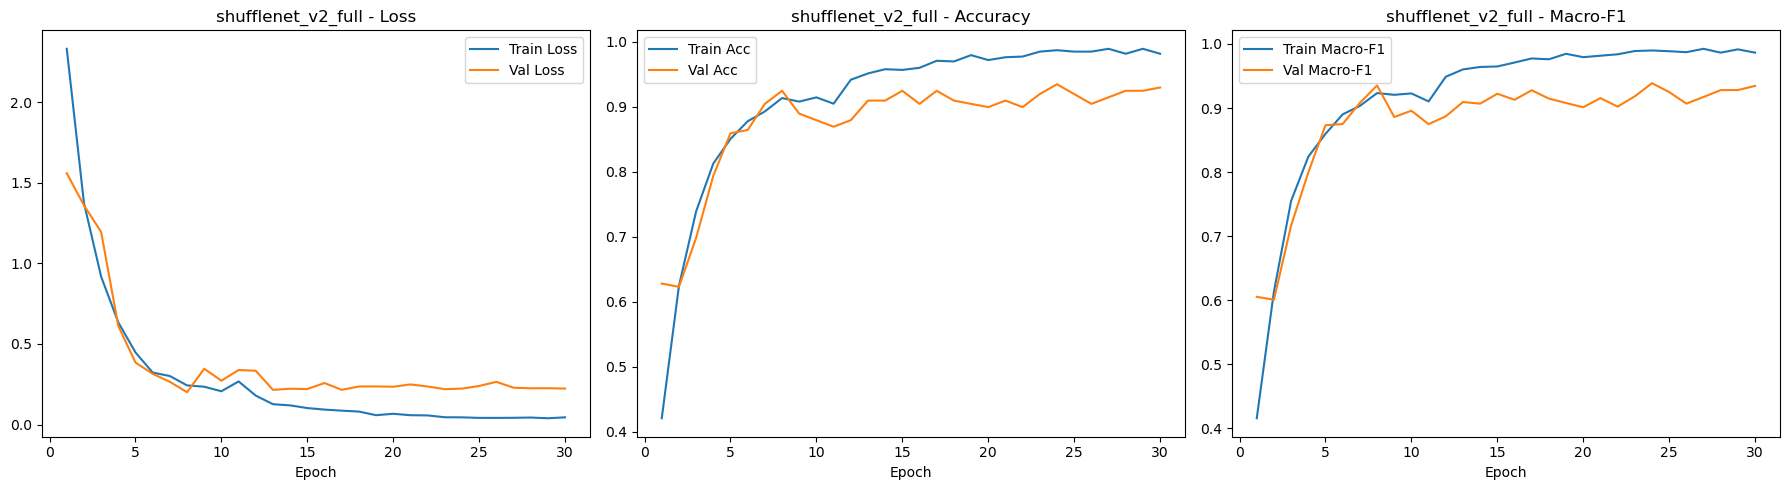

Saved curves to checkpoints/shufflenet_v2_full/curves.png


In [26]:
# ============================================================
# CELL 11: PLOT CURVES — loss / accuracy / macro-F1, train vs val
# ============================================================
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title(f"{RUN_TAG} - Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title(f"{RUN_TAG} - Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(epochs_range, history["train_f1"], label="Train Macro-F1")
axes[2].plot(epochs_range, history["val_f1"], label="Val Macro-F1")
axes[2].set_title(f"{RUN_TAG} - Macro-F1"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=300)
plt.show()
print(f"Saved curves to {CURVES_PATH}")

/tmp/ipykernel_48542/856668918.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_PATH))


Epoch:   0%|          | 0/7 [00:00<?, ?it/s]

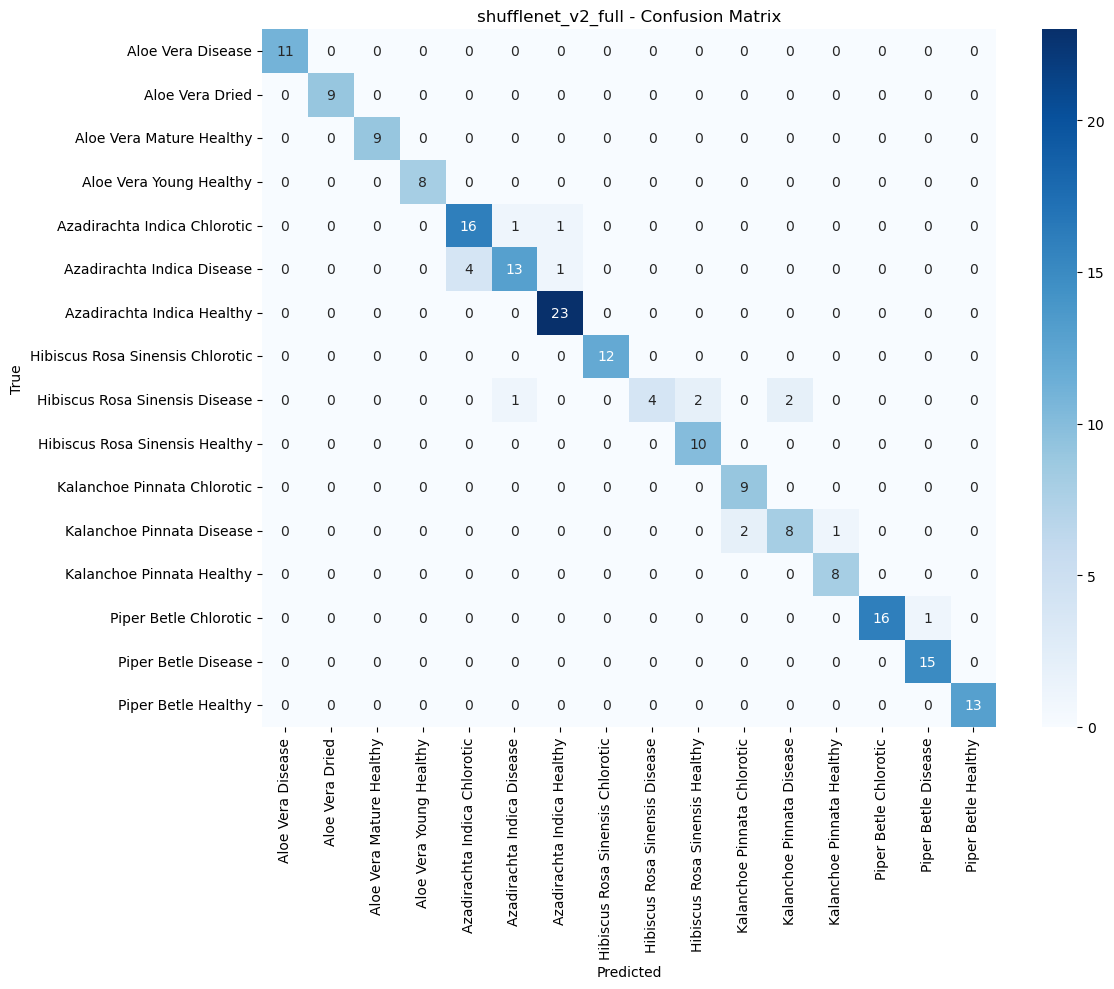

Saved confusion matrix to checkpoints/shufflenet_v2_full/confusion_matrix.png

=== FINAL TEST RESULTS ===
{
  "model": "shufflenet_v2",
  "train_mode": "full",
  "test_accuracy": 0.92,
  "test_macro_f1": 0.9158320654074612,
  "test_precision": 0.9290356691919192,
  "test_recall": 0.9202502970885325,
  "total_params": 1270004,
  "trainable_params": 1270004,
  "model_size_mb": 4.845,
  "inference_ms_per_image": 0.18,
  "best_val_macro_f1": 0.9387701006568852
}


In [27]:
# ============================================================
# CELL 12: FINAL TEST EVAL — loads best checkpoint, measures inference speed
# ============================================================
model.load_state_dict(torch.load(BEST_PATH))
model.eval()

sample_batch, _ = next(iter(test_loader))
sample_batch = sample_batch.to(DEVICE)
with torch.no_grad():
    start = time.time()
    for _ in range(20):
        _ = model(sample_batch)
    elapsed = time.time() - start
per_image_ms = (elapsed / (20 * sample_batch.size(0))) * 1000

test_loss, test_acc, test_f1, test_prec, test_rec = run_epoch(test_loader, train=False)

num_params = sum(p.numel() for p in model.parameters())
trainable_params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = num_params * 4 / (1024 ** 2)

results = {
    "model": MODEL_NAME, "train_mode": TRAIN_MODE,
    "test_accuracy": test_acc, "test_macro_f1": test_f1,
    "test_precision": test_prec, "test_recall": test_rec,
    "total_params": num_params, "trainable_params": trainable_params_count,
    "model_size_mb": round(model_size_mb, 3),
    "inference_ms_per_image": round(per_image_ms, 3),
    "best_val_macro_f1": best_val_f1,
}
# ============================================================
# CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = test_ds.classes

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"{RUN_TAG} - Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"Saved confusion matrix to {cm_path}")

print("\n=== FINAL TEST RESULTS ===")
print(json.dumps(results, indent=2))

with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

In [28]:
#run cell 1-3 before running bellow cell seperately if not let it as it is
# ============================================================
# STANDALONE: LOAD MODEL + RUN TEST PREDICTIONS LATER
# ============================================================
import os
import torch
import torch.nn as nn
import pandas as pd
from torchvision import models

# ---- CONFIG: pick which run's results you want ----
MODEL_NAME = "shufflenet_v2"   # mobilenet_v3_small | shufflenet_v2 | efficientnet_b0
TRAIN_MODE = "full"                  # full | partial | classifier_only

RUN_TAG = f"{MODEL_NAME}_{TRAIN_MODE}"
SAVE_DIR = os.path.join("checkpoints", RUN_TAG)
BEST_PATH = os.path.join(SAVE_DIR, "best_model.pth")

assert os.path.exists(BEST_PATH), f"No saved model found at {BEST_PATH} — train this combo first."

# ---- Rebuild architecture (must match training) ----
def build_model(name, num_classes):
    if name == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    elif name == "shufflenet_v2":
        m = models.shufflenet_v2_x1_0(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m

NUM_CLASSES = len(test_ds.classes)  # assumes test_ds already loaded from Cell 3
model = build_model(MODEL_NAME, NUM_CLASSES)
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print(f"Loaded best model for {RUN_TAG} from {BEST_PATH}")

# ---- Run test predictions ----
class_names = test_ds.classes
test_samples = test_ds.samples
prediction_log = []

idx = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        confidences = probs.max(dim=1).values

        for i in range(imgs.size(0)):
            filepath, true_idx = test_samples[idx]
            pred_idx = preds[i].item()
            prediction_log.append({
                "image_path": filepath,
                "true_class": class_names[true_idx],
                "predicted_class": class_names[pred_idx],
                "confidence": round(confidences[i].item(), 4),
                "correct": true_idx == pred_idx,
            })
            idx += 1

pred_log_df = pd.DataFrame(prediction_log)
pred_log_path = os.path.join(SAVE_DIR, "test_predictions_log.csv")
pred_log_df.to_csv(pred_log_path, index=False)

print(f"Saved per-image test predictions to {pred_log_path}")
print(f"Total test images: {len(pred_log_df)}")
print(f"Correct: {pred_log_df['correct'].sum()} | Incorrect: {(~pred_log_df['correct']).sum()}")
print("\n=== Sample of misclassified images ===")
print(pred_log_df[~pred_log_df['correct']].head(10).to_string(index=False))

Loaded best model for shufflenet_v2_full from checkpoints/shufflenet_v2_full/best_model.pth


/tmp/ipykernel_48542/875230606.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))


Saved per-image test predictions to checkpoints/shufflenet_v2_full/test_predictions_log.csv
Total test images: 200
Correct: 184 | Incorrect: 16

=== Sample of misclassified images ===
                                                                                         image_path                     true_class                predicted_class  confidence  correct
  Medicinal Plant Leaf Health Split Dataset/test/Azadirachta Indica Chlorotic/IMG20260107135908.png   Azadirachta Indica Chlorotic     Azadirachta Indica Disease      0.6971    False
  Medicinal Plant Leaf Health Split Dataset/test/Azadirachta Indica Chlorotic/IMG20260107140010.png   Azadirachta Indica Chlorotic     Azadirachta Indica Healthy      0.8815    False
    Medicinal Plant Leaf Health Split Dataset/test/Azadirachta Indica Disease/IMG20260107132510.png     Azadirachta Indica Disease     Azadirachta Indica Healthy      0.9900    False
    Medicinal Plant Leaf Health Split Dataset/test/Azadirachta Indica Disease/IMG202

=== PER-CLASS RESULTS (Test Set) ===
                                  precision  recall  f1-score  support
Aloe Vera Disease                    1.0000  1.0000    1.0000    11.00
Aloe Vera Dried                      1.0000  1.0000    1.0000     9.00
Aloe Vera Mature Healthy             1.0000  1.0000    1.0000     9.00
Aloe Vera Young Healthy              1.0000  1.0000    1.0000     8.00
Azadirachta Indica Chlorotic         0.8000  0.8889    0.8421    18.00
Azadirachta Indica Disease           0.8667  0.7222    0.7879    18.00
Azadirachta Indica Healthy           0.9200  1.0000    0.9583    23.00
Hibiscus Rosa Sinensis Chlorotic     1.0000  1.0000    1.0000    12.00
Hibiscus Rosa Sinensis Disease       1.0000  0.4444    0.6154     9.00
Hibiscus Rosa Sinensis Healthy       0.8333  1.0000    0.9091    10.00
Kalanchoe Pinnata Chlorotic          0.8182  1.0000    0.9000     9.00
Kalanchoe Pinnata Disease            0.8000  0.7273    0.7619    11.00
Kalanchoe Pinnata Healthy            0.8

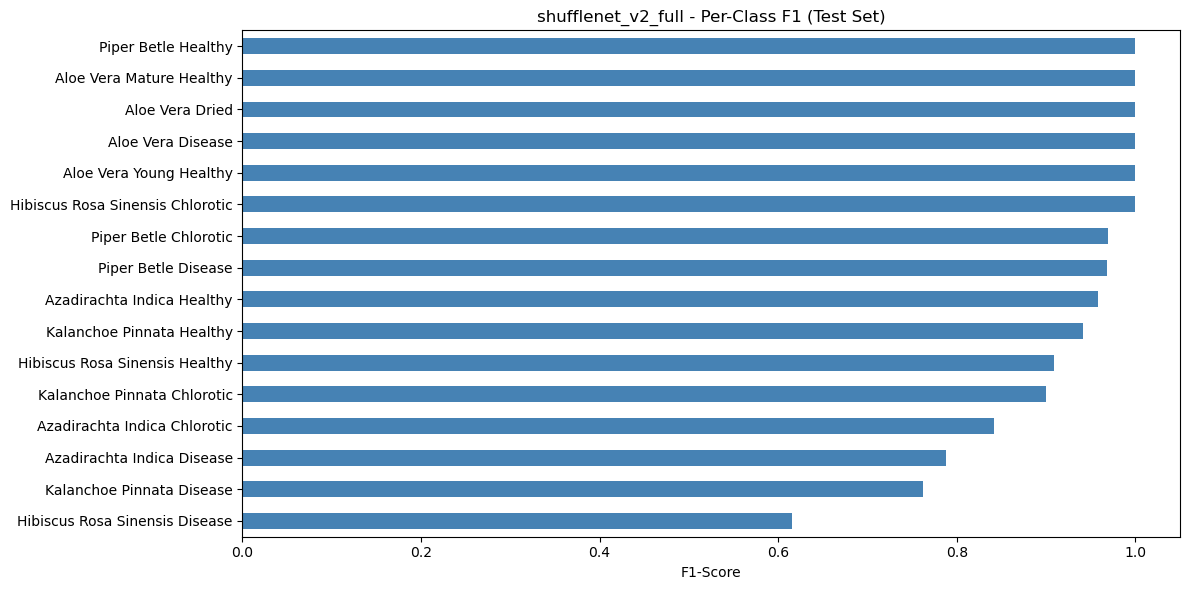

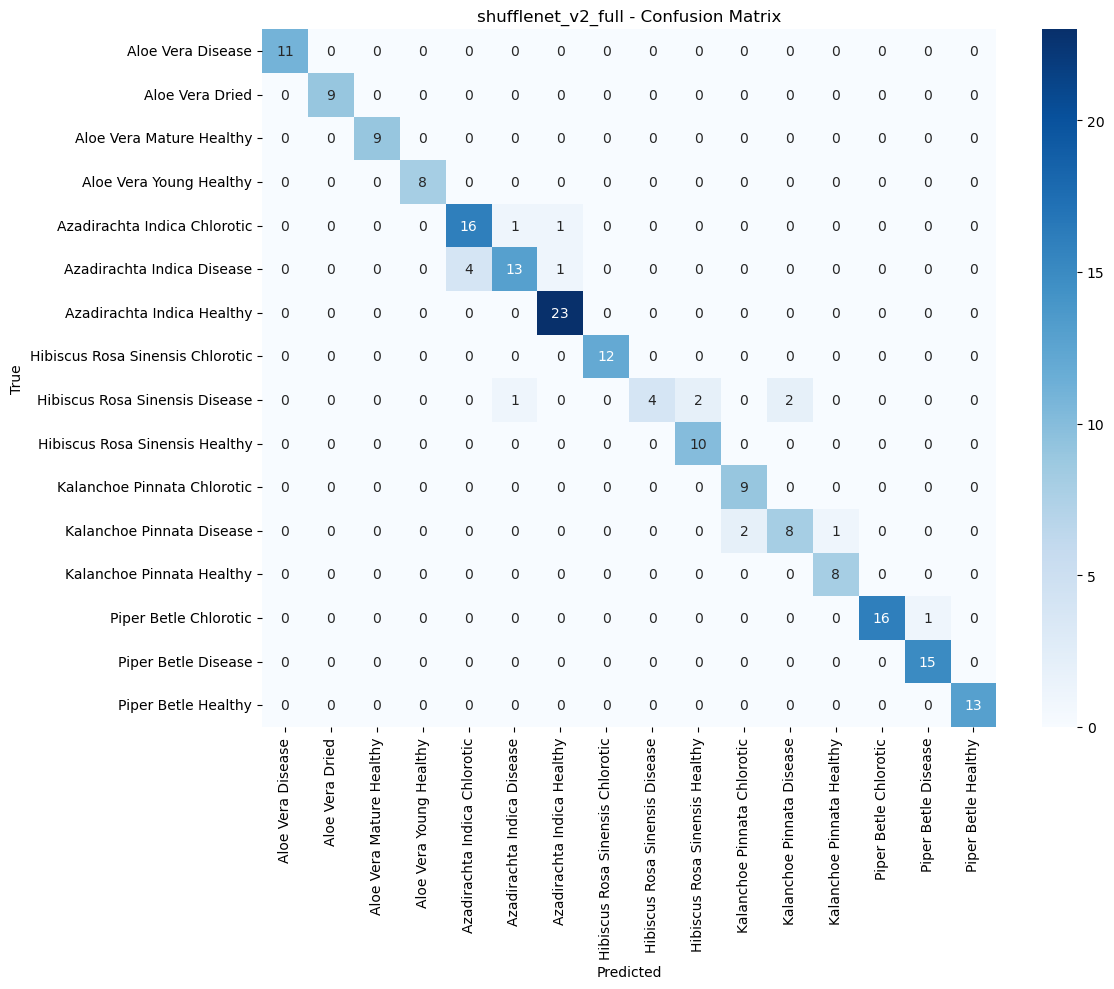


=== TOP MISCLASSIFICATIONS PER CLASS ===
Aloe Vera Disease: 11/11 correct | no misclassifications
Aloe Vera Dried: 9/9 correct | no misclassifications
Aloe Vera Mature Healthy: 9/9 correct | no misclassifications
Aloe Vera Young Healthy: 8/8 correct | no misclassifications
Azadirachta Indica Chlorotic: 16/18 correct | most confused with 'Azadirachta Indica Disease' (1 times)
Azadirachta Indica Disease: 13/18 correct | most confused with 'Azadirachta Indica Chlorotic' (4 times)
Azadirachta Indica Healthy: 23/23 correct | no misclassifications
Hibiscus Rosa Sinensis Chlorotic: 12/12 correct | no misclassifications
Hibiscus Rosa Sinensis Disease: 4/9 correct | most confused with 'Hibiscus Rosa Sinensis Healthy' (2 times)
Hibiscus Rosa Sinensis Healthy: 10/10 correct | no misclassifications
Kalanchoe Pinnata Chlorotic: 9/9 correct | no misclassifications
Kalanchoe Pinnata Disease: 8/11 correct | most confused with 'Kalanchoe Pinnata Chlorotic' (2 times)
Kalanchoe Pinnata Healthy: 8/8 corr

In [29]:
# ============================================================
# PER-CLASS RESULTS (from standalone prediction run)
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_true = pred_log_df["true_class"]
y_pred = pred_log_df["predicted_class"]

# per-class precision/recall/f1
report_dict = classification_report(y_true, y_pred, labels=class_names, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose().round(4)
print("=== PER-CLASS RESULTS (Test Set) ===")
print(report_df)

report_csv_path = os.path.join(SAVE_DIR, "per_class_report.csv")
report_df.to_csv(report_csv_path)
print(f"Saved per-class report to {report_csv_path}")

# per-class F1 bar chart
per_class_f1 = report_df.iloc[:len(class_names)]["f1-score"]
plt.figure(figsize=(12, 6))
per_class_f1.sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("F1-Score")
plt.title(f"{RUN_TAG} - Per-Class F1 (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "per_class_f1.png"), dpi=300)
plt.show()

# confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"{RUN_TAG} - Confusion Matrix")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

# top misclassification per class
print("\n=== TOP MISCLASSIFICATIONS PER CLASS ===")
misclass_rows = []
for i, true_cls in enumerate(class_names):
    row = cm[i].copy()
    correct = row[i]
    row[i] = 0
    total = cm[i].sum()
    if row.sum() > 0:
        top_idx = row.argmax()
        misclass_rows.append({
            "true_class": true_cls, "correct_predictions": correct, "total_samples": total,
            "most_confused_with": class_names[top_idx], "confused_count": row[top_idx],
        })
        print(f"{true_cls}: {correct}/{total} correct | most confused with '{class_names[top_idx]}' ({row[top_idx]} times)")
    else:
        misclass_rows.append({
            "true_class": true_cls, "correct_predictions": correct, "total_samples": total,
            "most_confused_with": "None (perfect)", "confused_count": 0,
        })
        print(f"{true_cls}: {correct}/{total} correct | no misclassifications")

misclass_df = pd.DataFrame(misclass_rows)
misclass_df.to_csv(os.path.join(SAVE_DIR, "misclassification_summary.csv"), index=False)
print(f"\nSaved misclassification summary to {os.path.join(SAVE_DIR, 'misclassification_summary.csv')}")